# Lesson 7 — Random variables, expectation & variance

*Part 1 · Lesson 7 of 20  ·  data: dice simulation · US Births 2014*

**←** [Lesson 6: Counting: permutations & combinations](06-counting.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb) **→**

**Same idea, another way:**  [Another dataset →](07-random-variables~another-dataset.ipynb)  ·  [The code behind it →](07-random-variables~the-code.ipynb)

**Welcome.** A *random variable* is just a rule that turns the outcome of a chancy
experiment into a **number** — the roll of a die, the count of doctor visits, the dollars
you win. Once outcomes are numbers, we can ask "what's the *typical* value?" and "how *spread out*
are they?" — the **expected value** and the **variance**. We'll watch a fair die's running
average glide toward its expected value (the famous *law of large numbers*), and then meet a
**real** random variable: the number of prenatal visits among 944 US births in 2014.

Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()
rng = np.random.default_rng(12)  # fixed seed -> reproducible; learner can change it
print("Ready.")

Ready.


## 1) What is a random variable?

A **random variable** (RV) is a rule that assigns a *number* to each outcome of a random
experiment. We write it with a capital letter, usually $X$.

- Roll a die: the outcome "the face showing" *is already* a number, $X \in \{1,2,3,4,5,6\}$.
- Toss 3 coins: let $X$ = "how many heads," so $X \in \{0,1,2,3\}$.
- Pick a random birth: let $X$ = "number of prenatal visits," a whole-number *count*.

A **probability distribution** lists every value $X$ can take and the probability of each,
written $P(X=x)$ or just $P(x)$. The probabilities are each between 0 and 1, and they sum to 1.

- **The math:** a function $P(x)$ with $\sum_x P(x) = 1$.
- **The meaning:** a complete "menu" of what can happen and how often.
- **The interpretation:** it describes the *long-run* behavior of the experiment, not any single trial.

## 2) A fair six-sided die — a distribution we know exactly

For a fair die, each face is equally likely, so $P(X=x) = \tfrac{1}{6}$ for every
$x \in \{1,2,3,4,5,6\}$. This is the simplest non-trivial distribution: flat, six bars of equal height.
Because we *know* it exactly, we can compute the true answers by hand and then check them by simulation.

Outcome  Probability
   1        0.1667
   2        0.1667
   3        0.1667
   4        0.1667
   5        0.1667
   6        0.1667

Probabilities sum to 1.0000  (must be 1).


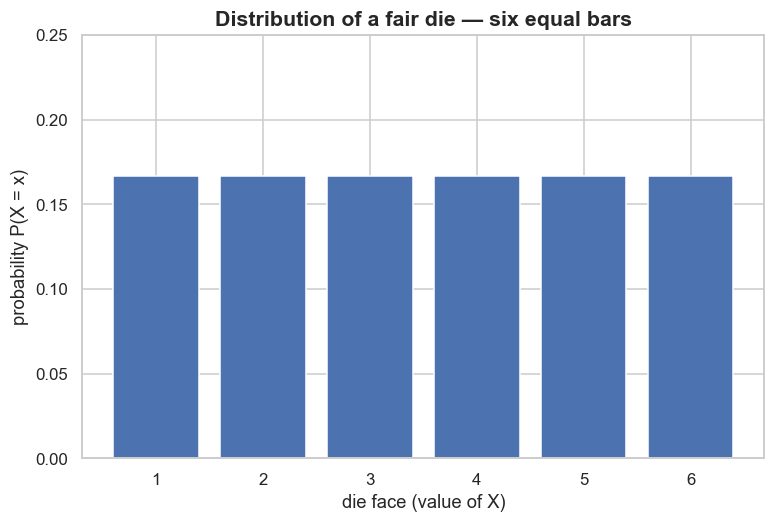

In [2]:
faces = np.array([1, 2, 3, 4, 5, 6])
probs = np.full(6, 1/6)          # each face has probability 1/6

print("Outcome  Probability")
for x, p in zip(faces, probs):
    print(f"   {x}        {p:.4f}")
print(f"\nProbabilities sum to {probs.sum():.4f}  (must be 1).")

fig, ax = plt.subplots()
ax.bar(faces, probs, color='#4c72b0', edgecolor='white')
ax.set_xlabel('die face (value of X)'); ax.set_ylabel('probability P(X = x)')
ax.set_title('Distribution of a fair die — six equal bars')
ax.set_ylim(0, 0.25)
plt.show()

## 3) Expected value E[X] — the "center of gravity"

The **expected value** is the probability-weighted average of all the values:

$$E[X] = \sum_x x \, P(x).$$

- **The math:** multiply each value by its probability and add them up.
- **The meaning:** the *balance point* of the distribution — where the bar chart would tip if it were
  a seesaw. It is the long-run *average* you'd get over many, many trials.
- **The interpretation:** $E[X]$ need not be a value $X$ can actually take. A die's expected value is
  **3.5**, yet you can never roll a 3.5. It's the average you converge to, not a prediction of one roll.

For the fair die: $E[X] = \tfrac{1}{6}(1+2+3+4+5+6) = \tfrac{21}{6} = 3.5.$

In [3]:
E = np.sum(faces * probs)        # sum of x * P(x)
print(f"E[X] = {E}   (the textbook value is 3.5)")

E[X] = 3.5   (the textbook value is 3.5)


## 4) Variance Var[X] and standard deviation — how spread out is it?

The **variance** measures how far, on average, the values land from the expected value —
using *squared* distances so that overshoots and undershoots don't cancel:

$$\operatorname{Var}[X] = \sum_x (x - \mu)^2 \, P(x), \qquad \mu = E[X].$$

The **standard deviation** is its square root, $\operatorname{SD}[X] = \sqrt{\operatorname{Var}[X]}$,
which brings us back to the original units (here, "die pips").

- **The math:** weight each squared distance by its probability and add.
- **The meaning:** variance is the typical *squared* miss; SD is the everyday "give or take."
- **The interpretation:** a small SD means outcomes huddle near $E[X]$; a large SD means they scatter.

For the fair die the exact answers are $\operatorname{Var}[X] \approx 2.9167$ and $\operatorname{SD}[X] \approx 1.7078$.

In [4]:
Var = np.sum((faces - E)**2 * probs)   # sum of (x - mu)^2 * P(x)
SD  = np.sqrt(Var)
print(f"Var[X] = {Var:.4f}   (textbook 2.9167)")
print(f"SD[X]  = {SD:.4f}   (textbook 1.7078)")

Var[X] = 2.9167   (textbook 2.9167)
SD[X]  = 1.7078   (textbook 1.7078)


## 5) The law of large numbers — watch the average converge

We *defined* $E[X]$ as the long-run average. The **law of large numbers** makes that precise:
as the number of trials grows, the **sample mean** (the average of the rolls so far) settles down
toward the true expected value $E[X]$.

Below we roll the die thousands of times and plot the **running average** after each roll. Early on it
jumps around; as rolls pile up it homes in on the black line at 3.5.

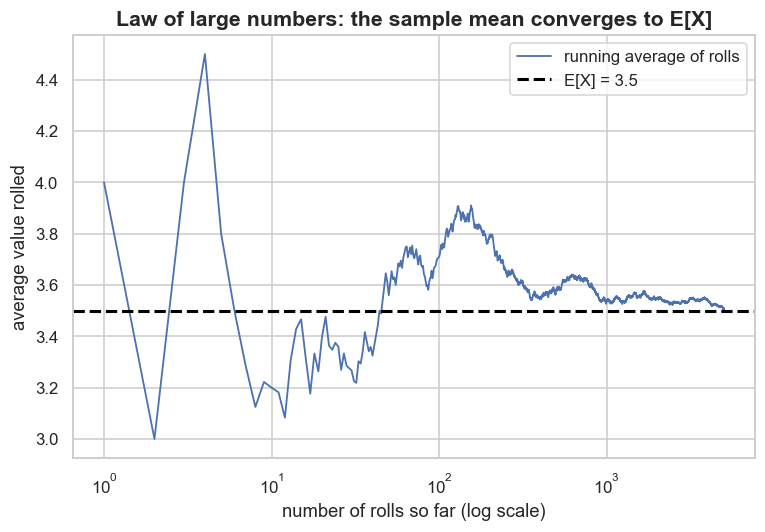

Average of first 10 rolls:    3.200
Average of all 5000 rolls: 3.509   (target: 3.5)


In [5]:
n_rolls = 5000                              # <- tinker: try 200, then 50000
rolls = rng.integers(1, 7, size=n_rolls)    # whole numbers 1..6, each equally likely

running_avg = np.cumsum(rolls) / np.arange(1, n_rolls + 1)

fig, ax = plt.subplots()
ax.plot(np.arange(1, n_rolls + 1), running_avg, color='#4c72b0', lw=1.2,
        label='running average of rolls')
ax.axhline(E, color='black', lw=2, ls='--', label=f'E[X] = {E}')
ax.set_xscale('log')                        # log x-axis spreads out the early, jumpy part
ax.set_xlabel('number of rolls so far (log scale)'); ax.set_ylabel('average value rolled')
ax.set_title('Law of large numbers: the sample mean converges to E[X]')
ax.legend(); plt.show()

print(f"Average of first 10 rolls:    {running_avg[9]:.3f}")
print(f"Average of all {n_rolls} rolls: {running_avg[-1]:.3f}   (target: {E})")

The same simulation also lets us check the **variance** empirically. The variance of the rolls we
actually observed should land near the exact $2.9167$ — and the more rolls, the closer it gets.

In [6]:
sim_var = rolls.var(ddof=0)        # population-style variance of the simulated rolls
print(f"Simulated variance of {n_rolls} rolls: {sim_var:.4f}")
print(f"Exact Var[X] for a fair die:        {Var:.4f}")

Simulated variance of 5000 rolls: 2.9387
Exact Var[X] for a fair die:        2.9167


## 6) Expected value of a bet — is the game fair?

Expected value shines when the numbers are **dollars**. Consider a game tied to one die roll:

> **Win 10 dollars if the die shows a 6; otherwise lose 2 dollars.**

Turn the payoff into a random variable. With probability $\tfrac{1}{6}$ you gain $+10$; with
probability $\tfrac{5}{6}$ you lose, i.e. $-2$. The expected payoff is

$$E[\text{payoff}] = \tfrac{1}{6}(10) + \tfrac{5}{6}(-2) = \tfrac{10}{6} - \tfrac{10}{6} = 0.$$

- **The meaning:** $E = 0$ is a **fair game** — over the long run you neither gain nor lose on average.
  A positive $E$ favors you; a negative $E$ (every casino game) bleeds you slowly.
- **The interpretation:** $E[\text{payoff}]=0$ does **not** mean any single play breaks even — each play
  you either win 10 dollars or lose 2. It means the *average* of many plays drifts toward 0 dollars per play.

In [7]:
win_amt, lose_amt = 10, -2
p_win = 1/6
E_payoff = p_win * win_amt + (1 - p_win) * lose_amt
E_payoff = round(E_payoff, 10) + 0.0   # round off a tiny float residual so 0 prints as 0.00
print(f"E[payoff] = (1/6)*{win_amt} + (5/6)*({lose_amt}) = ${E_payoff:.2f}  -> a fair game")

# Simulate playing the game many times and average the result.
n_plays = 100_000                       # <- tinker: try a small number like 20
die = rng.integers(1, 7, size=n_plays)
payoffs = np.where(die == 6, win_amt, lose_amt)
print(f"Average payoff over {n_plays:,} plays: ${payoffs.mean():.3f}  (heading to $0.00)")

E[payoff] = (1/6)*10 + (5/6)*(-2) = $0.00  -> a fair game
Average payoff over 100,000 plays: $-0.019  (heading to $0.00)


## 7) A REAL random variable — number of prenatal visits

Now a distribution we do **not** know in advance — we have to *estimate* it from data. The
**US Births 2014** dataset records, for each birth, the mother's number of prenatal (`visits`)
doctor appointments. Let the random variable be

$$X = \text{number of prenatal visits for a randomly chosen birth}.$$

The `visits` column has **56 missing values**, so we drop those rows first — you can only build a
distribution from births where the count was actually recorded.

In [8]:
births = sl.load_csv('births14.csv', url='https://www.openintro.org/data/csv/births14.csv')
print(f"Rows before dropping missing visits: {len(births)}")

visits = births['visits'].dropna()
n = len(visits)
print(f"Rows after dropna:                   {n}")
print(f"mean   = {visits.mean():.2f}")
print(f"var (sample, ddof=1) = {visits.var(ddof=1):.2f}")
print(f"min = {visits.min():.0f}   max = {visits.max():.0f}")

Rows before dropping missing visits: 1000
Rows after dropna:                   944
mean   = 11.35
var (sample, ddof=1) = 16.88
min = 0   max = 30


## 8) Build the empirical distribution: P(X = k) = count of k ÷ n

We do not *know* the true probabilities, so we estimate each from the data: the probability of
exactly $k$ visits is the **fraction of births** that had $k$ visits,

$$P(X = k) = \frac{\text{number of births with exactly } k \text{ visits}}{n}.$$

This is the **empirical** (data-driven) probability distribution. Because every birth lands in
exactly one bucket, these fractions sum to 1 — a genuine distribution.

In [9]:
counts = visits.value_counts().sort_index()      # how many births at each k
k_vals = counts.index.to_numpy(dtype=int)        # the values 0,1,2,...,30
P = counts.to_numpy() / n                         # P(X = k)

dist = pd.DataFrame({'k (visits)': k_vals, 'count': counts.to_numpy(), 'P(X=k)': P})
print(f"Probabilities sum to {P.sum():.4f}  (must be 1).")
print("\nA few rows of the empirical distribution:")
print(dist.head(12).to_string(index=False))
print("...")
print(dist.tail(4).to_string(index=False))

Probabilities sum to 1.0000  (must be 1).

A few rows of the empirical distribution:
 k (visits)  count   P(X=k)
          0     17 0.018008
          1      6 0.006356
          2      4 0.004237
          3     13 0.013771
          4     14 0.014831
          5     15 0.015890
          6     27 0.028602
          7     37 0.039195
          8     51 0.054025
          9     56 0.059322
         10    132 0.139831
         11     86 0.091102
...
 k (visits)  count   P(X=k)
         27      1 0.001059
         28      1 0.001059
         29      1 0.001059
         30      2 0.002119


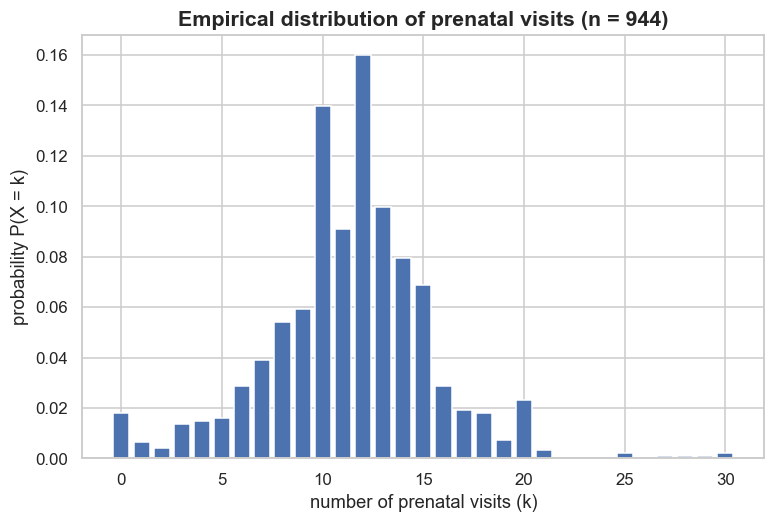

In [10]:
fig, ax = plt.subplots()
ax.bar(k_vals, P, color='#4c72b0', edgecolor='white')
ax.set_xlabel('number of prenatal visits (k)'); ax.set_ylabel('probability P(X = k)')
ax.set_title('Empirical distribution of prenatal visits (n = %d)' % n)
plt.show()

## 9) Compute E[X] and Var[X] FROM the distribution

The die formulas work on *any* distribution — including this real one. Using the empirical
probabilities $P(k)$:

$$E[X] = \sum_k k\,P(k), \qquad \operatorname{Var}[X] = \sum_k (k - E[X])^2\,P(k).$$

Two satisfying checks should fall out:

1. The distribution's $E[X]$ should equal the plain **data mean** of `visits`.
2. The distribution's $\operatorname{Var}[X]$ is the **population** variance — exactly
   `visits.var(ddof=0)`.

In [11]:
E_visits   = np.sum(k_vals * P)                       # sum k * P(k)
Var_visits = np.sum((k_vals - E_visits)**2 * P)       # sum (k - E)^2 * P(k)
SD_visits  = np.sqrt(Var_visits)

print(f"E[X] from distribution = {E_visits:.4f}")
print(f"data mean of visits    = {visits.mean():.4f}   <- should match E[X]")
print()
print(f"Var[X] from distribution      = {Var_visits:.4f}")
print(f"visits.var(ddof=0) (population) = {visits.var(ddof=0):.4f}   <- should match Var[X]")
print(f"visits.var(ddof=1) (sample)     = {visits.var(ddof=1):.4f}   <- a hair larger")
print()
print(f"SD[X] = {SD_visits:.4f} visits")

E[X] from distribution = 11.3517
data mean of visits    = 11.3517   <- should match E[X]

Var[X] from distribution      = 16.8594
visits.var(ddof=0) (population) = 16.8594   <- should match Var[X]
visits.var(ddof=1) (sample)     = 16.8772   <- a hair larger

SD[X] = 4.1060 visits


*(Optional fine print — safe to skip on a first read.)* **The ddof distinction, in one sentence:** the variance we computed from the distribution is the
**population** variance (it divides by $n$, i.e. `ddof=0`), which always sits a hair *below* the
**sample** variance (`ddof=1`, which divides by $n-1$ to correct for estimating the mean) — here
$16.86$ versus $16.88$. We'll explore *why* the sample version inflates it in a later lesson.

**Interpretation:** a randomly chosen 2014 US birth had, on average, about **11 prenatal visits**,
give or take roughly **4** ($\text{SD} \approx 4.1$). That "give or take" is the everyday meaning of the
standard deviation — though note this distribution is **right-skewed with a tall spike at 10–12 visits**,
so the SD is a rough symmetric summary of a lopsided shape, not a promise that visits spread out evenly
above and below the mean.

## 10) Law of large numbers again — but on real data

The die showed the sample mean converging to a *known* $E[X]$. Here we do the same with the **real**
distribution: draw many random births (**with replacement** — meaning the same birth can be picked more
than once, like rolling the same die again) and watch the running average of their visit counts settle
toward $E[X] \approx 11.35$ — the very number we computed from the full distribution.

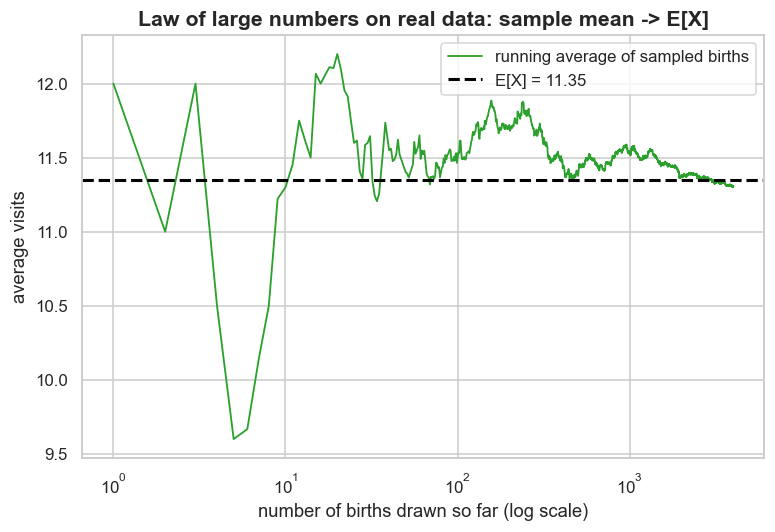

Average of first 10 draws:   11.30
Average of all 4000 draws: 11.31   (target E[X] = 11.35)


In [12]:
n_draws = 4000                                   # <- tinker: try 100, then 20000
sample = rng.choice(visits.to_numpy(), size=n_draws, replace=True)
running = np.cumsum(sample) / np.arange(1, n_draws + 1)

fig, ax = plt.subplots()
ax.plot(np.arange(1, n_draws + 1), running, color='#2ca02c', lw=1.2,
        label='running average of sampled births')
ax.axhline(E_visits, color='black', lw=2, ls='--', label=f'E[X] = {E_visits:.2f}')
ax.set_xscale('log')
ax.set_xlabel('number of births drawn so far (log scale)'); ax.set_ylabel('average visits')
ax.set_title('Law of large numbers on real data: sample mean -> E[X]')
ax.legend(); plt.show()

print(f"Average of first 10 draws:   {running[9]:.2f}")
print(f"Average of all {n_draws} draws: {running[-1]:.2f}   (target E[X] = {E_visits:.2f})")

## Now you try

Predict first, then change one thing and re-run:

1. In the **die** convergence cell, set `n_rolls = 200`. Does the running average still hug 3.5, or
   does it wander? Now try `n_rolls = 50000`. What does that say about how *fast* the law of large
   numbers works?
2. In the **bet** cell, change the payoff to `win_amt = 15` (keep `lose_amt = -2`). Recompute
   `E_payoff`. Is the game now fair, in your favor, or against you? Does the simulated average agree?
3. In the **real-data** convergence cell, set `n_draws = 100`. Run it a few times. How far can the
   final average stray from 11.35 with only 100 births — and why does that matter for small samples?

## What you learned

- A **random variable** turns chancy outcomes into numbers; its **probability distribution** lists
  every value and how likely it is (probabilities sum to 1).
- **Expected value** $E[X]=\sum_x x\,P(x)$ is the long-run average / balance point — it need not be an
  outcome you can ever observe (a die's is 3.5).
- **Variance** $\operatorname{Var}[X]=\sum_x (x-\mu)^2P(x)$ and its square root, the **SD**, measure
  spread — the everyday "give or take."
- The **law of large numbers** says the sample mean converges to $E[X]$ as trials pile up — we watched
  it happen for both a die and 944 real births.
- The **same formulas** describe a known die *and* an estimated real distribution; the
  distribution's variance is the **population** form (`ddof=0`), a hair below the sample form (`ddof=1`).

**Next:** Lesson 8 meets two famous *named* distributions for counts — the **binomial** and the
**Poisson** — and puts them to work on real births and earthquakes.

---

**← Previous:** [Lesson 6: Counting: permutations & combinations](06-counting.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb)

**Same idea, another way:**  [Another dataset →](07-random-variables~another-dataset.ipynb)  ·  [The code behind it →](07-random-variables~the-code.ipynb)